In [18]:
%run "coli starting run.ipynb"

In [10]:


score_borad = data_create(0,0,0,0)
for i in range(50):
    true_score = i*10+101
    score_borad = pd.concat([score_borad,data_create(40,my_floor(true_score,-2),true_score,0)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(20,my_floor(true_score,-2),true_score,1)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_create(40,my_floor(true_score,-2),true_score,2)]).reset_index(drop=True)

score_borad = pd.concat([score_borad,data_create(20,100,349,3)]).reset_index(drop=True)
score_borad = pd.concat([score_borad,data_create(20,500,350,3)]).reset_index(drop=True)

score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100.0,101,0,0,0,0,0,0,6.0,100.0
1,100.0,101,0,0,0,0,0,0,3.0,100.0
2,100.0,101,0,0,0,0,0,0,9.0,100.0
3,100.0,101,0,0,0,0,0,0,5.0,100.0
4,100.0,101,0,0,0,0,0,0,8.0,100.0
...,...,...,...,...,...,...,...,...,...,...
5035,500.0,350,0,0,0,0,0,3,7.0,500.0
5036,500.0,350,0,0,0,0,0,3,14.0,500.0
5037,500.0,350,0,0,0,0,0,3,17.0,500.0
5038,500.0,350,0,0,0,0,0,3,13.0,500.0


In [11]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
1221,330.0,221,0,19,10,11,3,0,19.0,200.0,130.0
213,170.0,121,0,19,10,11,1,0,19.0,100.0,70.0
2246,340.0,321,0,0,8,0,4,1,0.0,300.0,40.0
356,140.0,131,0,0,5,0,3,1,0.0,100.0,40.0
4216,550.0,521,0,11,17,3,8,0,11.0,500.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...
84,90.0,101,5,1,3,0,1,2,1.0,100.0,-10.0
2042,350.0,301,0,0,10,0,5,1,0.0,300.0,50.0
3666,530.0,461,5,6,5,5,3,2,6.0,400.0,130.0
1345,230.0,231,0,0,6,0,3,1,0.0,200.0,30.0


<AxesSubplot:xlabel='score', ylabel='true score'>

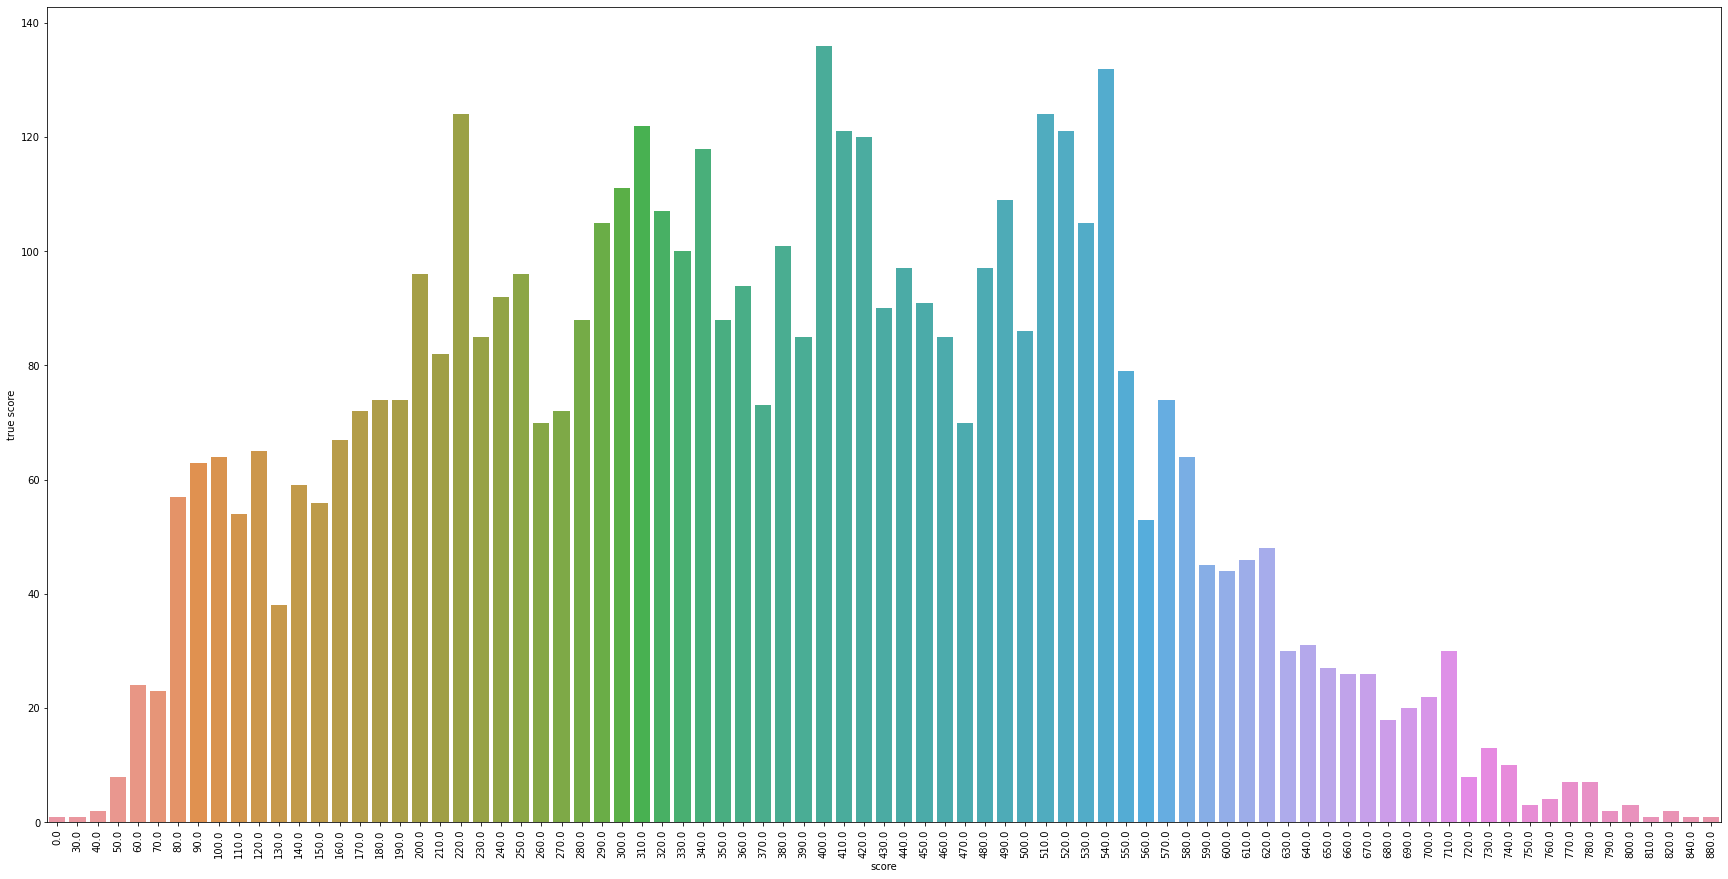

In [19]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

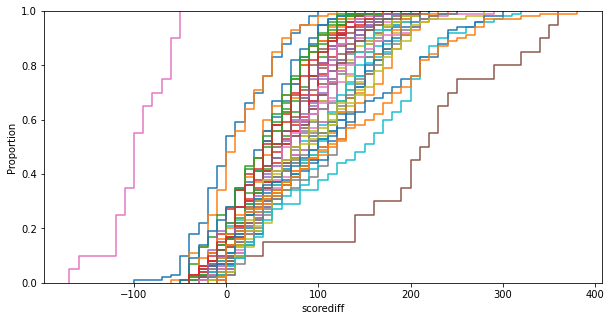

In [13]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [14]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

att count                    att win                  def count  \
type               0    1      2      3       0    1     2     3         0   
true score                                                                   
101             9.20  0.0   9.60    NaN    4.80  0.0  4.58   NaN     10.43   
111             8.97  0.0   8.15    NaN    4.67  0.0  3.90   NaN     11.12   
121            10.15  0.0   8.05    NaN    5.45  0.0  4.53   NaN     10.25   
131             7.78  0.0   9.03    NaN    4.38  0.0  5.42   NaN     10.10   
141            10.20  0.0   9.88    NaN    5.75  0.0  5.75   NaN      9.03   
151            10.10  0.0   7.80    NaN    6.15  0.0  4.95   NaN      8.57   
161             9.85  0.0   9.20    NaN    6.05  0.0  5.92   NaN      7.53   
171             8.50  0.0   8.60    NaN    5.83  0.0  5.62   NaN      8.03   
181             8.50  0.0   9.32    NaN    5.83  0.0  6.45   NaN      7.88   
191             8.60  0.0   8.78    NaN    5.88  0.0  6.47   NaN      5.53   
201             7.58  0.0  10.10    NaN    4.12  0.0  5.78   NaN     10.78   
211             9.18  0.0   8.93    NaN    5.08  0.0  5.35   NaN     11.15   
221             9.55  0.0   8.95    NaN    5.42  0.0  5.15   NaN     11.40   
231             9.95  0.0   8.18    NaN    5.45  0.0  4.92   NaN     10.38   
241            10.57  0.0   8.25    NaN    6.00  0.0  5.10   NaN     10.38   
251            10.43  0.0   7.20    NaN    6.38  0.0  4.85   NaN      9.35   
261             9.32  0.0   9.75    NaN    5.90  0.0  6.22   NaN      8.45   
271            10.75  0.0   9.65    NaN    6.83  0.0  6.50   NaN      8.97   
281             6.65  0.0  10.43    NaN    4.62  0.0  7.15   NaN      5.17   
291            10.40  0.0   8.35    NaN    7.58  0.0  6.20   NaN      8.07   
301             9.85  0.0   9.53    NaN    4.85  0.0  5.88   NaN     10.72   
311             9.07  0.0   8.60    NaN    4.88  0.0  4.85   NaN     11.30   
321             8.45  0.0   9.00    NaN    4.58  0.0  5.40   NaN     10.05   
331             6.95  0.0   9.12    NaN    3.92  0.0  5.78   NaN      8.38   
341             8.72  0.0   9.35    NaN    5.22  0.0  6.05   NaN      9.40   
349              NaN  NaN    NaN  10.30     NaN  NaN   NaN  9.60       NaN   
350              NaN  NaN    NaN  10.25     NaN  NaN   NaN  2.45       NaN   
351             8.72  0.0   8.05    NaN    5.55  0.0  5.35   NaN      7.67   
361             9.60  0.0   7.83    NaN    6.17  0.0  5.38   NaN      7.62   
371             8.90  0.0   8.75    NaN    6.03  0.0  6.03   NaN      7.50   
381             9.53  0.0   9.53    NaN    6.45  0.0  6.95   NaN      6.67   
391            10.70  0.0   8.03    NaN    7.45  0.0  6.30   NaN      6.40   
401             8.47  0.0   8.75    NaN    4.28  0.0  4.88   NaN      9.62   
411            10.72  0.0   9.20    NaN    5.60  0.0  5.15   NaN     11.47   
421             8.43  0.0  10.45    NaN    4.88  0.0  6.15   NaN     10.45   
431             8.53  0.0   7.58    NaN    4.80  0.0  4.70   NaN      9.65   
441             8.62  0.0   8.70    NaN    5.33  0.0  5.15   NaN      8.80   
451            10.30  0.0   8.60    NaN    6.60  0.0  5.78   NaN      9.15   
461             8.22  0.0   9.38    NaN    5.30  0.0  6.28   NaN      7.83   
471             7.45  0.0   9.53    NaN    4.95  0.0  6.60   NaN      6.95   
481            10.57  0.0   9.25    NaN    7.30  0.0  6.80   NaN      7.33   
491            11.38  0.0   9.12    NaN    7.95  0.0  6.88   NaN      7.75   
501             9.15  0.0   8.28    NaN    5.00  0.0  5.08   NaN     12.25   
511             9.50  0.0   7.38    NaN    5.38  0.0  4.45   NaN     12.38   
521             8.30  0.0  10.05    NaN    4.45  0.0  6.55   NaN     11.25   
531             8.68  0.0   7.83    NaN    5.50  0.0  5.22   NaN     10.82   
541             9.53  0.0   8.15    NaN    6.05  0.0  5.35   NaN     10.70   
551             9.55  0.0   9.62    NaN    6.35  0.0  7.17   NaN     10.03   
561             7.70  0.0   8.70 

In [15]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399]

att count                   att win                  def count  \
type               0    1     2      3       0    1     2     3         0   
true score                                                                  
301             9.85  0.0  9.53    NaN    4.85  0.0  5.88   NaN     10.72   
311             9.07  0.0  8.60    NaN    4.88  0.0  4.85   NaN     11.30   
321             8.45  0.0  9.00    NaN    4.58  0.0  5.40   NaN     10.05   
331             6.95  0.0  9.12    NaN    3.92  0.0  5.78   NaN      8.38   
341             8.72  0.0  9.35    NaN    5.22  0.0  6.05   NaN      9.40   
349              NaN  NaN   NaN  10.30     NaN  NaN   NaN  9.60       NaN   
350              NaN  NaN   NaN  10.25     NaN  NaN   NaN  2.45       NaN   
351             8.72  0.0  8.05    NaN    5.55  0.0  5.35   NaN      7.67   
361             9.60  0.0  7.83    NaN    6.17  0.0  5.38   NaN      7.62   
371             8.90  0.0  8.75    NaN    6.03  0.0  6.03   NaN      7.50   
381             9.53  0.0  9.53    NaN    6.45  0.0  6.95   NaN      6.67   
391            10.70  0.0  8.03    NaN    7.45  0.0  6.30   NaN      6.40   

                               def win                  int_score         \
type           1      2      3       0     1     2    3         0      1   
true score                                                                 
301         7.30  10.05    NaN    3.30  2.80  2.83  NaN     300.0  300.0   
311         7.25   9.95    NaN    3.95  3.05  3.25  NaN     300.0  300.0   
321         6.00   8.90    NaN    3.48  2.65  3.05  NaN     300.0  300.0   
331         5.30   8.40    NaN    3.10  2.30  3.02  NaN     300.0  300.0   
341         5.30   8.20    NaN    3.45  2.25  3.00  NaN     300.0  300.0   
349          NaN    NaN   2.15     NaN   NaN   NaN  1.4       NaN    NaN   
350          NaN    NaN  13.90     NaN   NaN   NaN  2.4       NaN    NaN   
351         4.45   7.53    NaN    2.60  2.65  3.17  NaN     300.0  300.0   
361         3.50   5.85    NaN    2.52  1.80  2.52  NaN     300.0  300.0   
371         2.80   4.80    NaN    2.88  1.95  2.20  NaN     300.0  300.0   
381         1.65   4.20    NaN    2.52  1.10  1.90  NaN     300.0  300.0   
391         0.50   3.25    NaN    2.25  0.40  1.27  NaN     300.0  300.0   

                         play_time                      score                 \
type            2      3         0    1      2      3       0      1       2   
true score                                                                     
301         300.0    NaN      9.85  0.0  10.20    NaN  338.75  311.0  365.25   
311         300.0    NaN      9.07  0.0   8.95    NaN  361.00  319.0  357.50   
321         300.0    NaN      8.45  0.0   9.45    NaN  356.50  319.5  374.50   
331         300.0    NaN      6.95  0.0   9.62    NaN  357.50  316.0  388.75   
341         300.0    NaN      8.72  0.0   9.88    NaN  379.00  314.5  396.00   
349           NaN  100.0       NaN  NaN    NaN  10.30     NaN    NaN     NaN   
350           NaN  500.0       NaN  NaN    NaN  10.25     NaN    NaN     NaN   
351         300.0    NaN      8.72  0.0   8.55    NaN  380.50  335.0  400.00   
361         300.0    NaN      9.60  0.0   8.38    NaN  388.75  319.0  400.25   
371         300.0    NaN      8.90  0.0   9.18    NaN  403.00  330.5  411.25   
381         300.0    NaN      9.53  0.0   9.93    NaN  407.25  316.5  428.25   
391         300.0    NaN     10.70  0.0   8.32    NaN  420.00  307.0  414.50   

                  scorediff                      skiped time                 
type            3         0     1       2      3           0    1    2    3  
true score                                                                   
301           NaN     38.75  11.0   65.25    NaN         0.0  0.0  5.0  NaN  
311           NaN     61.00  19.0   57.50    NaN         0.0  0.0  5.0  NaN  
321           NaN     56.50  19.5   74.50    NaN         0.0  0.0  5.0  NaN  
331           NaN     57.50  16.0   88.75    

In [16]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[400:499][['att count','def count','scorediff']]

att count                 def count                  scorediff  \
type               0    1      2   3         0     1      2   3         0   
true score                                                                  
401             8.47  0.0   8.75 NaN      9.62  7.90   8.75 NaN     38.00   
411            10.72  0.0   9.20 NaN     11.47  6.15  10.22 NaN     67.50   
421             8.43  0.0  10.45 NaN     10.45  5.50   9.95 NaN     61.00   
431             8.53  0.0   7.58 NaN      9.65  6.65   7.40 NaN     56.75   
441             8.62  0.0   8.70 NaN      8.80  5.40   7.53 NaN     73.25   
451            10.30  0.0   8.60 NaN      9.15  3.55   6.97 NaN     95.00   
461             8.22  0.0   9.38 NaN      7.83  4.00   6.83 NaN     90.75   
471             7.45  0.0   9.53 NaN      6.95  1.85   5.28 NaN     88.50   
481            10.57  0.0   9.25 NaN      7.33  1.35   4.20 NaN    119.50   
491            11.38  0.0   9.12 NaN      7.75  0.30   3.58 NaN    126.00   

                              
type           1       2   3  
true score                    
401          8.0   61.25 NaN  
411          4.5   70.50 NaN  
421         20.0   84.75 NaN  
431         31.0   77.50 NaN  
441         24.0   90.50 NaN  
451         17.0   97.75 NaN  
461         35.0  119.25 NaN  
471         13.0  119.00 NaN  
481          9.0  121.25 NaN  
491          3.0  126.50 NaN